In [1]:
using Printf
using Plots

gr()
default(size=(1100, 520), margin=6Plots.mm, grid=true)


In [2]:
X_LO = 0.0
X_HI = 8.0

f1(x) = 5 - 24x + 17x^2 - (11/3)*x^3 + (1/4)*x^4
f2(x) = 5 - 24*(X_HI - x) + 17*(X_HI - x)^2 - (11/3)*(X_HI - x)^3 + (1/4)*(X_HI - x)^4

N_GRID = 2000
xgrid = collect(range(X_LO, X_HI, length=N_GRID))

f1_vals = f1.(xgrid)
f2_vals = f2.(xgrid)

2000-element Vector{Float64}:
 47.66666666666674
 47.442954733253146
 47.22004193483963
 46.99792660723574
 46.776607087790694
 46.55608171539302
 46.33634883046989
 46.11740677498801
 45.89925389245252
 45.6818885279082
 45.46530902793859
 45.24951374066643
 45.034501015753335
  ⋮
  3.9761048011545475
  4.066512602556194
  4.157450924307002
  4.248921161899889
  4.34092471236684
  4.433462974278862
  4.526537347746094
  4.620149234417755
  4.714300037482075
  4.808991161666424
  4.904224013237246
  5.0

In [ ]:
function argmin_on_grid(vals)
    i = argmin(vals)
    return (xgrid[i], vals[i], i)
end

x1_star, f1_star, i1 = argmin_on_grid(f1_vals)
x2_star, f2_star, i2 = argmin_on_grid(f2_vals)
F_star = (f1_star, f2_star)

f2_at_x1 = f2_vals[i1]
f1_at_x2 = f1_vals[i2]

println("\n=== Идеальная (утопическая) точка ===")
@printf("min f1: x1* = %.6f, f1* = %.8f, f2(x1*) = %.8f\n", x1_star, f1_star, f2_at_x1)
@printf("min f2: x2* = %.6f, f2* = %.8f, f1(x2*) = %.8f\n", x2_star, f2_star, f1_at_x2)
@printf("F* (утопическая) = (f1*, f2*) = (%.8f, %.8f)\n", f1_star, f2_star)

p_f = plot(xgrid, f1_vals, label="f1(x)", xlabel="x", ylabel="f(x)", title="f1(x), f2(x) на [$(X_LO), $(X_HI)]")
plot!(p_f, xgrid, f2_vals, label="f2(x)")
scatter!(p_f, [x1_star], [f1_star], label="min f1", ms=5)
scatter!(p_f, [x2_star], [f2_star], label="min f2", ms=5)

p_f

In [ ]:
@inline function dominates(a1, a2, b1, b2)
    return (a1 <= b1) && (a2 <= b2) && ((a1 < b1) || (a2 < b2))
end

function pareto_mask(f1v, f2v)
    n = length(f1v)
    mask = trues(n)
    for i in 1:n
        if !mask[i]
            continue
        end
        for j in 1:n
            if i == j
                continue
            end
            if dominates(f1v[j], f2v[j], f1v[i], f2v[i])
                mask[i] = false
                break
            end
        end
    end
    return mask
end

pmask = pareto_mask(f1_vals, f2_vals)
pareto_x = xgrid[pmask]
pareto_f1 = f1_vals[pmask]
pareto_f2 = f2_vals[pmask]

ord = sortperm(pareto_x)
pareto_x = pareto_x[ord]
pareto_f1 = pareto_f1[ord]
pareto_f2 = pareto_f2[ord]

gap_th = (X_HI - X_LO) / 40
pareto_f1_line = Float64[]
pareto_f2_line = Float64[]
for k in 1:length(pareto_x)
    if k > 1 && (pareto_x[k] - pareto_x[k-1]) > gap_th
        push!(pareto_f1_line, NaN)
        push!(pareto_f2_line, NaN)
    end
    push!(pareto_f1_line, pareto_f1[k])
    push!(pareto_f2_line, pareto_f2[k])
end

@printf("Pareto points (grid) = %d\n", length(pareto_x))

Pareto points (grid) = 502


In [4]:
println("\n=== SWO (Sum of Weighted Objectives) ===")

phi_swo(x, λ1, λ2) = λ1 * f1(x) + λ2 * f2(x)

function minimize_swo_on_grid(λ1, λ2)
    φ_vals = phi_swo.(xgrid, λ1, λ2)
    i = argmin(φ_vals)
    xstar = xgrid[i]
    return (xstar, φ_vals[i], (f1_vals[i], f2_vals[i]), i)
end

λ_grid = collect(range(0.05, 0.95, length=19))
lambdas = [(λ, 1 - λ) for λ in λ_grid]

swo_x = Float64[]
swo_f1 = Float64[]
swo_f2 = Float64[]
swo_idx = Int[]

println("Решения SWO (минимизация λ1 f1 + λ2 f2 на сетке x):")
for (λ1, λ2) in lambdas
    xstar, φstar, (ff1, ff2), i = minimize_swo_on_grid(λ1, λ2)
    push!(swo_x, xstar)
    push!(swo_f1, ff1)
    push!(swo_f2, ff2)
    push!(swo_idx, i)
    @printf("λ=(%.3f, %.3f) -> x*=%.6f, f=(%.6f, %.6f), φ=%.8f\n", λ1, λ2, xstar, ff1, ff2, φstar)
end



=== SWO (Sum of Weighted Objectives) ===
Решения SWO (минимизация λ1 f1 + λ2 f2 на сетке x):
λ=(0.050, 0.950) -> x*=6.939470, f=(11.542515, -5.389775), φ=-4.54316083
λ=(0.100, 0.900) -> x*=6.883442, f=(10.663461, -5.318950), φ=-3.72070853
λ=(0.150, 0.850) -> x*=6.823412, f=(9.807608, -5.197232), φ=-2.94650619
λ=(0.200, 0.800) -> x*=6.767384, f=(9.085505, -5.043672), φ=-2.21783683
λ=(0.250, 0.750) -> x*=6.711356, f=(8.434069, -4.854194), φ=-1.53212843
λ=(0.300, 0.700) -> x*=6.659330, f=(7.889605, -4.648309), φ=-0.88693503
λ=(0.350, 0.650) -> x*=6.603302, f=(7.365350, -4.396679), φ=-0.27996893
λ=(0.400, 0.600) -> x*=6.551276, f=(6.933529, -4.137319), φ=0.29102066
λ=(0.450, 0.550) -> x*=6.499250, f=(6.552138, -3.855152), φ=0.82812845
λ=(0.500, 0.500) -> x*=1.548774, f=(-3.576051, 6.242754), φ=1.33335143
λ=(0.550, 0.450) -> x*=1.500750, f=(-3.855152, 6.552138), φ=0.82812845
λ=(0.600, 0.400) -> x*=1.448724, f=(-4.137319, 6.933529), φ=0.29102066
λ=(0.650, 0.350) -> x*=1.396698, f=(-4.396679

In [ ]:
λ_show = [(0.2, 0.8), (0.5, 0.5), (0.8, 0.2)]

p_phi = plot(xlabel="x", ylabel="φ(x)", title="Взвешенная сумма φ(x) для разных λ")
for (λ1, λ2) in λ_show
    φ_vals = phi_swo.(xgrid, λ1, λ2)
    i = argmin(φ_vals)
    plot!(p_phi, xgrid, φ_vals, label=@sprintf("λ=(%.1f,%.1f)", λ1, λ2))
    scatter!(p_phi, [xgrid[i]], [φ_vals[i]], ms=4, label="")
end

p_phi

In [5]:
function check_theorem_swo_grid(xstar_idx)
    f1s = f1_vals[xstar_idx]
    f2s = f2_vals[xstar_idx]
    for j in eachindex(xgrid)
        if dominates(f1_vals[j], f2_vals[j], f1s, f2s)
            return (false, j)
        end
    end
    return (true, 0)
end

println("\nПроверка теоремы 1 (недоминируемость найденных x* на сетке):")
all_ok = true
for (k, (λ1, λ2)) in enumerate(lambdas)
    i = swo_idx[k]
    ok, j = check_theorem_swo_grid(i)
    all_ok &= ok
    if ok
        @printf("k=%02d λ=(%.3f,%.3f): OK (x* недоминируем на сетке)\n", k, λ1, λ2)
    else
        @printf("k=%02d λ=(%.3f,%.3f): FAIL (доминирует x=%.6f, f=(%.6f,%.6f))\n",
            k, λ1, λ2, xgrid[j], f1_vals[j], f2_vals[j])
    end
end
println(all_ok ? "Итог: на выбранной сетке теорема подтверждается для всех весов." :
                "Итог: найдены нарушения на сетке (возможна грубая сетка/численная погрешность).")



Проверка теоремы 1 (недоминируемость найденных x* на сетке):
k=01 λ=(0.050,0.950): OK (x* недоминируем на сетке)
k=02 λ=(0.100,0.900): OK (x* недоминируем на сетке)
k=03 λ=(0.150,0.850): OK (x* недоминируем на сетке)
k=04 λ=(0.200,0.800): OK (x* недоминируем на сетке)
k=05 λ=(0.250,0.750): OK (x* недоминируем на сетке)
k=06 λ=(0.300,0.700): OK (x* недоминируем на сетке)
k=07 λ=(0.350,0.650): OK (x* недоминируем на сетке)
k=08 λ=(0.400,0.600): OK (x* недоминируем на сетке)
k=09 λ=(0.450,0.550): OK (x* недоминируем на сетке)
k=10 λ=(0.500,0.500): OK (x* недоминируем на сетке)
k=11 λ=(0.550,0.450): OK (x* недоминируем на сетке)
k=12 λ=(0.600,0.400): OK (x* недоминируем на сетке)
k=13 λ=(0.650,0.350): OK (x* недоминируем на сетке)
k=14 λ=(0.700,0.300): OK (x* недоминируем на сетке)
k=15 λ=(0.750,0.250): OK (x* недоминируем на сетке)
k=16 λ=(0.800,0.200): OK (x* недоминируем на сетке)
k=17 λ=(0.850,0.150): OK (x* недоминируем на сетке)
k=18 λ=(0.900,0.100): OK (x* недоминируем на сетке)
k=

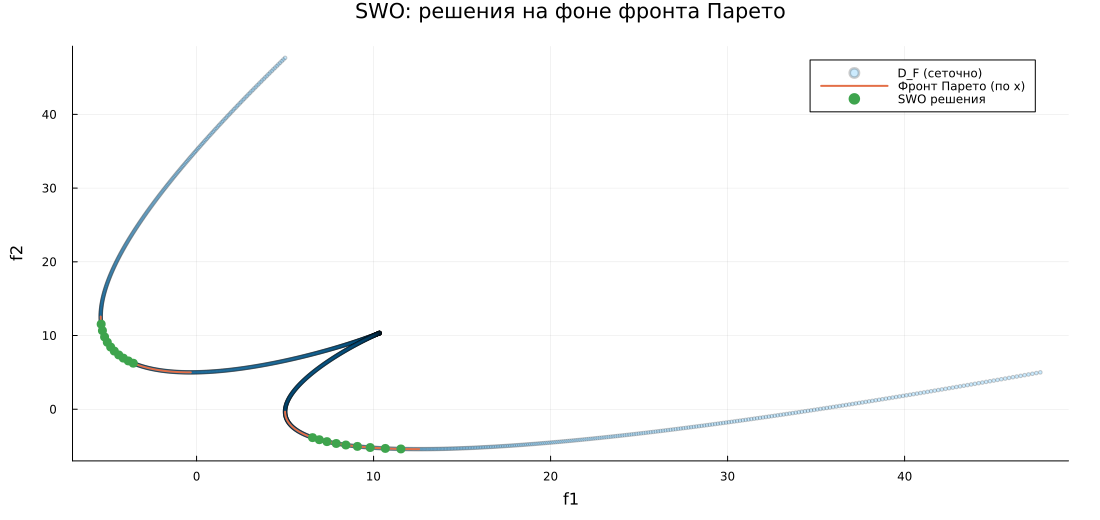

In [ ]:
p = scatter(f1_vals, f2_vals, ms=2, alpha=0.20, label="D_F (сеточно)",
    xlabel="f1", ylabel="f2", title="SWO: решения, фронт Парето и идеальная точка")
plot!(p, pareto_f1_line, pareto_f2_line, lw=2, label="Фронт Парето (по x)")

scatter!(p, swo_f1, swo_f2, ms=5, label="SWO решения", markerstrokewidth=0)

scatter!(p, [f1_star], [f2_at_x1], ms=7, marker=:diamond, label="x1*: min f1 (достижимая точка)")
scatter!(p, [f1_at_x2], [f2_star], ms=7, marker=:diamond, label="x2*: min f2 (достижимая точка)")

scatter!(p, [F_star[1]], [F_star[2]], ms=9, marker=:star5, label="F* (утопическая)")

p